# Taller 3 — Estado hídrico de la planta (SOLUCIÓN)

**Asignatura:** TAG2027 — Relación Suelo Agua Planta | UDLA
**Unidad:** 3 — El agua en la planta
**RAA:** RAA5
**Duración:** 3 horas
**Ejercicio vinculado:** Ejercicio 2

> **Versión con soluciones para el docente.** Las celdas `# TODO` están resueltas y se agregan respuestas sugeridas a las preguntas de interpretación.

---

## Objetivos

Al finalizar este taller serás capaz de:
1. Calcular el gradiente de potencial hídrico en el continuo suelo-planta-atmósfera (SPAC)
2. Calcular el déficit de presión de vapor (DPV) y la transpiración a partir de la conductancia estomática
3. Ajustar un modelo de respuesta estomática al potencial hídrico foliar
4. Calcular e interpretar la eficiencia de uso del agua (WUE instantánea e intrínseca)
5. Estimar la extracción de agua por las raíces en un perfil de suelo

---

## Instrucciones

1. Ejecuta cada celda en orden (Shift + Enter)
2. Completa las celdas marcadas con `# TODO`
3. Responde las preguntas de interpretación en celdas de texto
4. Entrega el notebook con todas las celdas ejecutadas

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/frzambra/RSPA-TAG-UDLA/blob/main/labs/taller-03/taller-03_solucion.ipynb)

In [1]:
# ========================================
# Celda de setup — Ejecutar primero
# ========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('✓ Setup completo.')

✓ Setup completo.


---
## Parte 1: Gradiente de potencial hídrico en el SPAC (35 min)

El agua se mueve desde donde el potencial hídrico (Ψ) es **mayor** (menos negativo) hacia donde es **menor** (más negativo). El potencial de la atmósfera depende de la temperatura y la humedad relativa:

$$\Psi_{atm} = \frac{R\,T}{V_w} \cdot \ln\left(\frac{HR}{100}\right)$$

con $R$ = 8.314 J/mol·K, $T$ en Kelvin y $V_w$ = 1.8 × 10⁻⁵ m³/mol. El resultado queda en Pa; dividimos por 10⁶ para obtener MPa.

El flujo de agua se describe con la analogía de la **ley de Ohm**:

$$J = \frac{\Delta\Psi}{R} \quad \Rightarrow \quad R = \frac{\Delta\Psi}{J}$$

### Datos: una vid en dos escenarios

Se midió Ψ en cada compartimento de una vid a mediodía, en un día con T = 25 °C y HR = 50 %, en dos situaciones: **suelo bien regado** y **suelo seco** (10 días sin riego).

In [2]:
# Potencial hídrico (MPa) en cada compartimento
spac = pd.DataFrame({
    'Compartimento': ['Suelo', 'Raíz', 'Xilema', 'Hoja', 'Atmósfera'],
    'Psi_regado_MPa': [-0.02, -0.30, -0.60, -1.00, np.nan],
    'Psi_seco_MPa':   [-0.80, -1.10, -1.40, -1.80, np.nan]
})

T_aire = 25   # °C
HR_aire = 50  # %

print('Potencial hídrico por compartimento (falta la atmósfera):')
spac

Potencial hídrico por compartimento (falta la atmósfera):


,Compartimento,Psi_regado_MPa,Psi_seco_MPa
0,Suelo,-0.02,-0.8
1,Raíz,-0.30,-1.1
2,Xilema,-0.60,-1.4
3,Hoja,-1.00,-1.8
4,Atmósfera,NaN,NaN


In [3]:
# SOLUCIÓN — TODO 1.1: Potencial hídrico de la atmósfera

def psi_atm(T_C, HR):
    R = 8.314        # J/mol·K
    Vw = 1.8e-5      # m³/mol
    T_K = T_C + 273.15
    return R * T_K / Vw * np.log(HR / 100) / 1e6   # Pa → MPa

psi_a = psi_atm(T_aire, HR_aire)
spac.loc[spac['Compartimento'] == 'Atmósfera', ['Psi_regado_MPa', 'Psi_seco_MPa']] = psi_a
print(f'Ψatm = {psi_a:.1f} MPa')

spac

Ψatm = -95.5 MPa


,Compartimento,Psi_regado_MPa,Psi_seco_MPa
0,Suelo,-0.020000,-0.800000
1,Raíz,-0.300000,-1.100000
2,Xilema,-0.600000,-1.400000
3,Hoja,-1.000000,-1.800000
4,Atmósfera,-95.454804,-95.454804


In [4]:
# Celda de validación
if 'psi_atm' in dir():
    ok = np.isclose(psi_atm(25, 50), -95.4, atol=0.5) and np.isclose(psi_atm(14, 75), -38.2, atol=0.5)
    print('✓ Ψatm correcto' if ok else '⚠ Revisa la función psi_atm (¿T en Kelvin? ¿resultado en MPa?)')
else:
    print('⚠ Define la función psi_atm primero')

✓ Ψatm correcto


In [5]:
# SOLUCIÓN — TODO 1.2: ΔΨ por tramo y % del total

tramos = pd.DataFrame({
    'Tramo': ['Suelo → Raíz', 'Raíz → Xilema', 'Xilema → Hoja', 'Hoja → Atmósfera'],
    'dPsi_regado': -np.diff(spac['Psi_regado_MPa'].values),
    'dPsi_seco': -np.diff(spac['Psi_seco_MPa'].values)
})
tramos['Pct_regado'] = tramos['dPsi_regado'] / tramos['dPsi_regado'].sum() * 100
tramos['Pct_seco'] = tramos['dPsi_seco'] / tramos['dPsi_seco'].sum() * 100

tramos.round(2)

,Tramo,dPsi_regado,dPsi_seco,Pct_regado,Pct_seco
0,Suelo → Raíz,0.28,0.30,0.29,0.32
1,Raíz → Xilema,0.30,0.30,0.31,0.32
2,Xilema → Hoja,0.40,0.40,0.42,0.42
3,Hoja → Atmósfera,94.45,93.65,98.97,98.94


In [6]:
# Celda de validación
if 'tramos' in dir():
    ok = (np.allclose(tramos['dPsi_regado'][:3], [0.28, 0.30, 0.40], atol=0.01)
          and np.isclose(tramos['Pct_regado'].iloc[3], 98.97, atol=0.1))
    print('✓ ΔΨ y porcentajes correctos' if ok else '⚠ Revisa el signo y el orden de los tramos')
else:
    print('⚠ Crea el DataFrame tramos primero')

✓ ΔΨ y porcentajes correctos


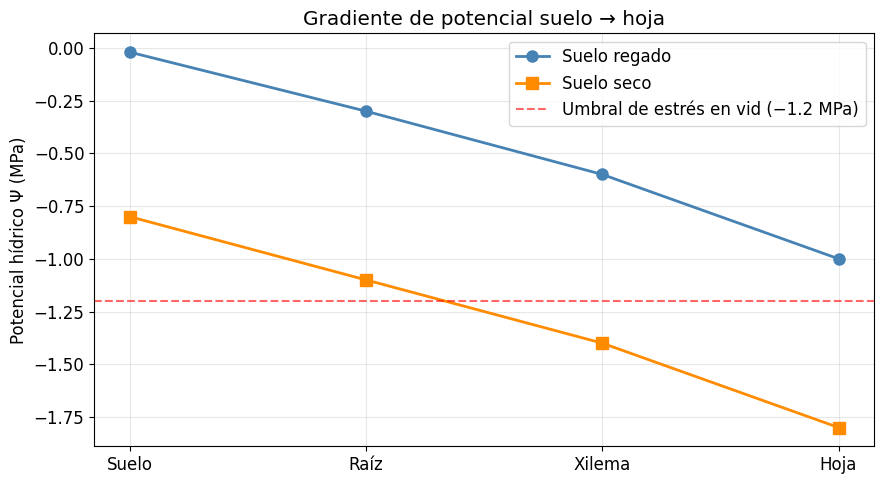

In [7]:
# Perfil de potencial dentro de la planta (sin la atmósfera, que está fuera de escala)
fig, ax = plt.subplots(figsize=(9, 5))
comp = spac['Compartimento'][:4]
ax.plot(comp, spac['Psi_regado_MPa'][:4], 'o-', color='steelblue', linewidth=2, markersize=8, label='Suelo regado')
ax.plot(comp, spac['Psi_seco_MPa'][:4], 's-', color='darkorange', linewidth=2, markersize=8, label='Suelo seco')
ax.axhline(-1.2, color='red', linestyle='--', alpha=0.6, label='Umbral de estrés en vid (−1.2 MPa)')
ax.set_ylabel('Potencial hídrico Ψ (MPa)')
ax.set_title('Gradiente de potencial suelo → hoja')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# SOLUCIÓN — TODO 1.3: Resistencia hidráulica suelo → hoja (ley de Ohm)
J_regado = 5.0   # mmol H₂O m⁻² s⁻¹
J_seco = 1.5     # mmol H₂O m⁻² s⁻¹

psi = spac.set_index('Compartimento')
R_regado = (psi.loc['Suelo', 'Psi_regado_MPa'] - psi.loc['Hoja', 'Psi_regado_MPa']) / J_regado
R_seco = (psi.loc['Suelo', 'Psi_seco_MPa'] - psi.loc['Hoja', 'Psi_seco_MPa']) / J_seco

print(f'Resistencia suelo→hoja (regado): {R_regado:.3f} MPa·m²·s/mmol')
print(f'Resistencia suelo→hoja (seco):   {R_seco:.3f} MPa·m²·s/mmol')
print(f'La resistencia aumenta {R_seco / R_regado:.1f} veces con el suelo seco')

Resistencia suelo→hoja (regado): 0.196 MPa·m²·s/mmol
Resistencia suelo→hoja (seco):   0.667 MPa·m²·s/mmol
La resistencia aumenta 3.4 veces con el suelo seco


In [9]:
# Celda de validación
if 'R_seco' in dir():
    ok = np.isclose(R_regado, 0.196, atol=0.005) and np.isclose(R_seco, 0.667, atol=0.005)
    print('✓ Resistencias correctas' if ok else '⚠ Revisa: R = (Ψsuelo − Ψhoja) / J')
else:
    print('⚠ Calcula R_regado y R_seco primero')

✓ Resistencias correctas


### Pregunta de interpretación

1. ¿En qué tramo se concentra la mayor caída de potencial? ¿Qué estructura la regula?
2. La diferencia Ψsuelo − Ψhoja es casi la misma en ambos escenarios (≈ 1 MPa), pero el flujo con suelo seco es tres veces menor. ¿Qué cambió? ¿Dónde crees que aumentó la resistencia?
3. En el escenario seco, ¿por qué la planta no puede simplemente bajar más su Ψhoja para seguir absorbiendo agua?

### Respuesta sugerida (Parte 1)

**1.** El tramo **hoja → atmósfera** concentra ≈ 99 % de la caída total (94.4 de 95.4 MPa en el escenario regado). Lo regulan los **estomas**: son la resistencia variable que controla todo el flujo.

**2.** Con ΔΨ suelo→hoja casi igual (0.98 vs 1.00 MPa) y un flujo 3.3 veces menor, la resistencia hidráulica subió de 0.196 a 0.667 MPa·m²·s/mmol (3.4 veces). El aumento está sobre todo en la **interfaz suelo-raíz**: al secarse el suelo cae su conductividad hidráulica (el agua queda en poros cada vez más finos), se pierde contacto entre raíz y suelo y las raíces se contraen. En la planta también aumenta la resistencia por **embolismo** (cavitación) en el xilema. Además, los estomas se cierran, lo que reduce la transpiración que "tira" del agua.

**3.** Porque un Ψhoja más negativo aumenta la tensión en el xilema y el riesgo de **cavitación** (ruptura de la columna de agua y embolismo), que puede ser irreversible. Por eso la planta cierra estomas antes de llegar a ese punto: sacrifica fotosíntesis para proteger su sistema de transporte. En vid, −1.8 MPa ya indica estrés severo (umbral de manejo ≈ −1.2 MPa).

---
## Parte 2: Curso diario de la transpiración (40 min)

Se registró cada hora, en una vid de la zona central durante un día de verano, la temperatura (T), la humedad relativa (HR), la conductancia estomática ($g_s$, con porómetro) y el potencial hídrico foliar (Ψhoja, con cámara de Scholander).

### Fórmulas

Presión de vapor de saturación (ecuación de Tetens, FAO-56):

$$e_s = 0.6108 \cdot \exp\left(\frac{17.27\,T}{T + 237.3}\right) \quad [\text{kPa}]$$

Déficit de presión de vapor:

$$DPV = e_s - e_a = e_s \cdot \left(1 - \frac{HR}{100}\right) \quad [\text{kPa}]$$

Transpiración (la forma $E = g_s \times DPV$ vista en clase, con el DPV expresado como fracción de la presión atmosférica $P_{atm}$ ≈ 101.3 kPa):

$$E = g_s \cdot \frac{DPV}{P_{atm}} \times 1000 \quad [\text{mmol H}_2\text{O m}^{-2}\,\text{s}^{-1}]$$

In [10]:
# Mediciones horarias en vid — día de verano, zona central
dia = pd.DataFrame({
    'Hora':     [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
    'T_C':      [14, 16, 19, 22, 25, 27, 29, 30, 31, 30, 28, 25, 22],
    'HR_pct':   [75, 68, 58, 48, 40, 35, 30, 28, 27, 29, 33, 40, 48],
    'gs_mol':   [0.10, 0.22, 0.30, 0.32, 0.30, 0.25, 0.18, 0.14, 0.12, 0.13, 0.15, 0.12, 0.06],  # mol H₂O m⁻² s⁻¹
    'Psi_hoja': [-0.40, -0.60, -0.80, -1.00, -1.15, -1.30, -1.40, -1.45, -1.45, -1.40, -1.30, -1.10, -0.80]  # MPa
})
P_atm = 101.3  # kPa

dia

,Hora,T_C,HR_pct,gs_mol,Psi_hoja
0,7,14,75,0.10,-0.40
1,8,16,68,0.22,-0.60
2,9,19,58,0.30,-0.80
3,10,22,48,0.32,-1.00
4,11,25,40,0.30,-1.15
5,12,27,35,0.25,-1.30
6,13,29,30,0.18,-1.40
7,14,30,28,0.14,-1.45
8,15,31,27,0.12,-1.45
9,16,30,29,0.13,-1.40


In [11]:
# SOLUCIÓN — TODO 2.1: DPV de cada hora

def es(T_C):
    return 0.6108 * np.exp(17.27 * T_C / (T_C + 237.3))

def dpv(T_C, HR):
    return es(T_C) * (1 - HR / 100)

dia['DPV_kPa'] = dpv(dia['T_C'], dia['HR_pct'])

dia[['Hora', 'T_C', 'HR_pct', 'DPV_kPa']].round(2)

,Hora,T_C,HR_pct,DPV_kPa
0,7,14,75,0.40
1,8,16,68,0.58
2,9,19,58,0.92
3,10,22,48,1.37
4,11,25,40,1.90
5,12,27,35,2.32
6,13,29,30,2.80
7,14,30,28,3.06
8,15,31,27,3.28
9,16,30,29,3.01


In [12]:
# SOLUCIÓN — TODO 2.2: Transpiración de cada hora

dia['E_mmol'] = dia['gs_mol'] * dia['DPV_kPa'] / P_atm * 1000
hora_E_max = dia.loc[dia['E_mmol'].idxmax(), 'Hora']
hora_DPV_max = dia.loc[dia['DPV_kPa'].idxmax(), 'Hora']

print(f'E máxima: {dia["E_mmol"].max():.2f} mmol m⁻² s⁻¹ a las {hora_E_max}:00')
print(f'DPV máximo: {dia["DPV_kPa"].max():.2f} kPa a las {hora_DPV_max}:00')

E máxima: 5.72 mmol m⁻² s⁻¹ a las 12:00
DPV máximo: 3.28 kPa a las 15:00


In [13]:
# Celda de validación
if 'E_mmol' in dia.columns and 'DPV_kPa' in dia.columns:
    ok = (np.isclose(dia['DPV_kPa'].max(), 3.28, atol=0.02)
          and np.isclose(dia['E_mmol'].max(), 5.72, atol=0.05)
          and dia.loc[dia['E_mmol'].idxmax(), 'Hora'] == 12)
    print('✓ DPV y E correctos' if ok else '⚠ Revisa las fórmulas de es, DPV y E')
else:
    print('⚠ Calcula DPV_kPa y E_mmol primero')

✓ DPV y E correctos


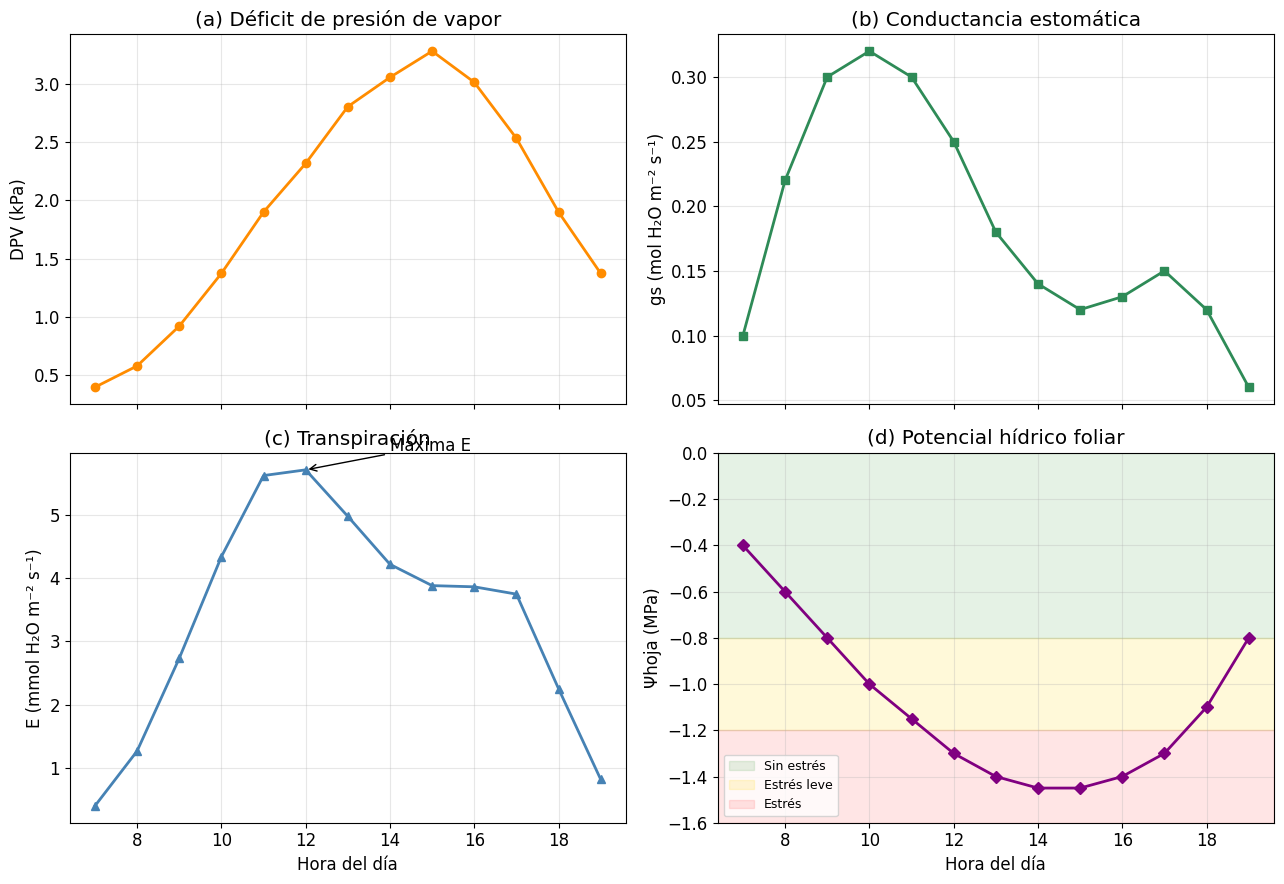

In [14]:
# SOLUCIÓN — TODO 2.3: Panel de 4 gráficos del curso diario

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

axes[0, 0].plot(dia['Hora'], dia['DPV_kPa'], 'o-', color='darkorange', linewidth=2)
axes[0, 0].set_ylabel('DPV (kPa)')
axes[0, 0].set_title('(a) Déficit de presión de vapor')

axes[0, 1].plot(dia['Hora'], dia['gs_mol'], 's-', color='seagreen', linewidth=2)
axes[0, 1].set_ylabel('gs (mol H₂O m⁻² s⁻¹)')
axes[0, 1].set_title('(b) Conductancia estomática')

axes[1, 0].plot(dia['Hora'], dia['E_mmol'], '^-', color='steelblue', linewidth=2)
axes[1, 0].set_ylabel('E (mmol H₂O m⁻² s⁻¹)')
axes[1, 0].set_title('(c) Transpiración')
axes[1, 0].annotate('Máxima E', xy=(hora_E_max, dia['E_mmol'].max()),
                    xytext=(hora_E_max + 2, dia['E_mmol'].max() + 0.3),
                    arrowprops=dict(arrowstyle='->', color='black'))

axes[1, 1].plot(dia['Hora'], dia['Psi_hoja'], 'D-', color='purple', linewidth=2)
axes[1, 1].axhspan(-0.8, 0, color='green', alpha=0.1, label='Sin estrés')
axes[1, 1].axhspan(-1.2, -0.8, color='gold', alpha=0.15, label='Estrés leve')
axes[1, 1].axhspan(-1.6, -1.2, color='red', alpha=0.1, label='Estrés')
axes[1, 1].set_ylim(-1.6, 0)
axes[1, 1].set_ylabel('Ψhoja (MPa)')
axes[1, 1].set_title('(d) Potencial hídrico foliar')
axes[1, 1].legend(loc='lower left', fontsize=9)

for ax in axes[1]:
    ax.set_xlabel('Hora del día')
for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# SOLUCIÓN — TODO 2.4: Estado hídrico de cada hora

dia['Estado'] = pd.cut(dia['Psi_hoja'],
                       bins=[-np.inf, -1.2, -0.8, 0],
                       labels=['Estrés', 'Estrés leve', 'Sin estrés'])
horas_estado = dia['Estado'].value_counts()

print('Horas en cada estado hídrico:')
horas_estado

Horas en cada estado hídrico:


Estado
Estrés         6
Estrés leve    5
Sin estrés     2
Name: count, dtype: int64

### Pregunta de interpretación

1. ¿A qué hora es máxima la transpiración? ¿Coincide con la hora de máximo DPV? ¿Por qué?
2. Entre las 12:00 y las 16:00 el DPV sigue subiendo, pero E baja. ¿Qué está haciendo la planta y con qué propósito?
3. Si midieras Ψhoja con la cámara de Scholander a las 14:00 de este día, ¿qué recomendarías al productor?

### Respuesta sugerida (Parte 2)

**1.** E es máxima a las **12:00** (5.72 mmol m⁻² s⁻¹), mientras que el DPV es máximo a las **15:00** (3.28 kPa). No coinciden porque E = gs × DPV: en la mañana ambos factores suben, pero desde el mediodía la planta **cierra parcialmente los estomas** (gs baja de 0.32 a 0.12) y esa caída pesa más que el aumento del DPV.

**2.** Es la **depresión de mediodía** de la conductancia estomática. Con DPV alto y Ψhoja cayendo bajo −1.2 MPa (señal hidráulica y ABA), la planta cierra estomas para limitar la pérdida de agua y evitar que Ψhoja siga bajando hasta niveles de riesgo de cavitación. El costo es menos entrada de CO₂ y menos fotosíntesis en las horas de más luz.

**3.** A las 14:00 Ψhoja = −1.45 MPa, bajo el umbral de −1.2 MPa: la vid está en **estrés** y pasa 6 horas del día en esa condición (12:00 a 17:00). Se recomienda **regar** (o adelantar el riego programado). Si el objetivo es un déficit controlado para calidad de uva tinta, confirmar con el potencial de base (pre-amanecer): si también está bajo, el estrés ya no es solo por la demanda atmosférica del mediodía, sino por falta de agua en el suelo.

---
## Parte 3: Respuesta estomática al déficit hídrico (35 min)

Durante un ciclo de secado del suelo se midió, en la misma vid, la conductancia estomática a mediodía junto con Ψhoja. La relación sigue una curva **sigmoide**:

$$g_s = \frac{g_{max}}{1 + \exp\left[k\,(\Psi_{50} - \Psi_{hoja})\right]}$$

| Parámetro | Significado |
|-----------|-------------|
| $g_{max}$ | Conductancia máxima (planta sin estrés) |
| $\Psi_{50}$ | Ψhoja al cual gs cae al **50 %** de $g_{max}$ |
| $k$ | Pendiente: qué tan brusco es el cierre estomático |

Vamos a estimar estos parámetros ajustando el modelo a los datos con `curve_fit`.

In [16]:
# Ciclo de secado: Ψhoja (MPa) y gs (mol H₂O m⁻² s⁻¹) a mediodía
secado = pd.DataFrame({
    'Psi_hoja': [-0.3, -0.5, -0.7, -0.9, -1.0, -1.1, -1.2, -1.3, -1.4, -1.5, -1.7, -1.9],
    'gs_mol':   [0.373, 0.315, 0.343, 0.305, 0.281, 0.246, 0.177, 0.146, 0.091, 0.104, 0.025, 0.010]
})

def modelo_gs(psi, gmax, k, psi50):
    """Respuesta sigmoide de gs a Ψhoja"""
    return gmax / (1 + np.exp(k * (psi50 - psi)))

secado

,Psi_hoja,gs_mol
0,-0.3,0.373
1,-0.5,0.315
2,-0.7,0.343
3,-0.9,0.305
4,-1.0,0.281
5,-1.1,0.246
6,-1.2,0.177
7,-1.3,0.146
8,-1.4,0.091
9,-1.5,0.104


In [17]:
# SOLUCIÓN — TODO 3.1: Ajuste del modelo sigmoide

params, cov = curve_fit(modelo_gs, secado['Psi_hoja'], secado['gs_mol'], p0=[0.3, 5, -1.0])
gmax, k, psi50 = params

print(f'gmax  = {gmax:.3f} mol m⁻² s⁻¹')
print(f'k     = {k:.2f} MPa⁻¹')
print(f'Ψ50   = {psi50:.2f} MPa')

gmax  = 0.357 mol m⁻² s⁻¹
k     = 5.07 MPa⁻¹
Ψ50   = -1.23 MPa


In [18]:
# Celda de validación
if 'psi50' in dir():
    ok = np.isclose(psi50, -1.23, atol=0.05) and np.isclose(gmax, 0.357, atol=0.02)
    print('✓ Ajuste correcto' if ok else '⚠ Revisa los argumentos de curve_fit (x = Psi_hoja, y = gs_mol)')
else:
    print('⚠ Ajusta el modelo primero')

✓ Ajuste correcto


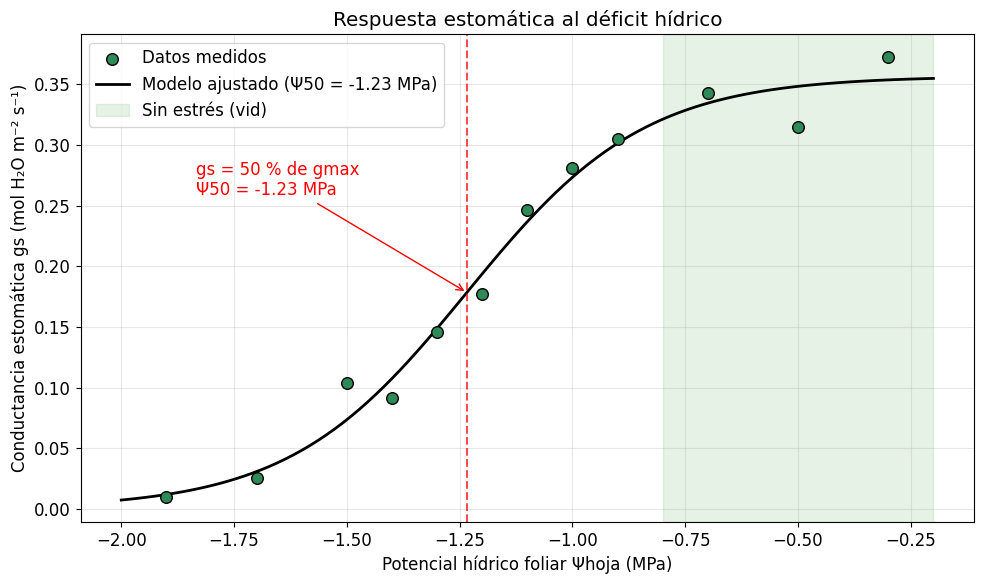

In [19]:
# SOLUCIÓN — TODO 3.2: Datos + curva ajustada

psi_suave = np.linspace(-2.0, -0.2, 100)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(secado['Psi_hoja'], secado['gs_mol'], s=70, color='seagreen', edgecolors='black',
           zorder=3, label='Datos medidos')
ax.plot(psi_suave, modelo_gs(psi_suave, gmax, k, psi50), color='black', linewidth=2,
        label=f'Modelo ajustado (Ψ50 = {psi50:.2f} MPa)')
ax.axvline(psi50, color='red', linestyle='--', alpha=0.7)
ax.annotate(f'gs = 50 % de gmax\nΨ50 = {psi50:.2f} MPa',
            xy=(psi50, gmax / 2), xytext=(psi50 - 0.6, gmax / 2 + 0.08),
            arrowprops=dict(arrowstyle='->', color='red'), color='red')
ax.axvspan(-0.8, -0.2, color='green', alpha=0.1, label='Sin estrés (vid)')
ax.set_xlabel('Potencial hídrico foliar Ψhoja (MPa)')
ax.set_ylabel('Conductancia estomática gs (mol H₂O m⁻² s⁻¹)')
ax.set_title('Respuesta estomática al déficit hídrico')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Pregunta de interpretación

1. ¿Qué significa el valor de Ψ50 que obtuviste? ¿Qué porcentaje de gmax conserva la planta en el umbral de riego de la vid (−1.2 MPa)?
2. ¿Qué implicancia tiene esto para la fotosíntesis y el crecimiento si se espera a que Ψhoja llegue a −1.5 MPa para regar?
3. Un cultivo con Ψ50 = −0.8 MPa y otro con Ψ50 = −1.8 MPa: ¿cuál es más "conservador" con el agua? ¿Cuál tolera mejor la sequía manteniendo la fotosíntesis?

### Respuesta sugerida (Parte 3)

**1.** Ψ50 ≈ **−1.23 MPa**: a ese potencial la vid ya cerró los estomas a la mitad de su conductancia máxima (gmax ≈ 0.36 mol m⁻² s⁻¹). En el umbral de riego (−1.2 MPa) conserva ≈ 54 % de gmax: el umbral de manejo coincide con el punto donde el cierre estomático se vuelve importante.

**2.** A −1.5 MPa la gs cae a ≈ 0.07 (≈ 20 % de gmax). Como el CO₂ entra por el mismo poro, la fotosíntesis cae fuertemente y el crecimiento de brotes y bayas se detiene. Esperar a ese nivel implica perder días de producción de biomasa; en vid vinífera puede buscarse un estrés moderado por calidad, pero no uno severo y prolongado.

**3.** El cultivo con **Ψ50 = −0.8 MPa** es más **conservador** (isohídrico): cierra estomas temprano, protege su estado hídrico pero deja de fotosintetizar antes. El de **Ψ50 = −1.8 MPa** (anisohídrico) mantiene los estomas abiertos a potenciales más negativos: sigue fotosintetizando con menos agua, pero con más riesgo de cavitación si la sequía se prolonga.

---
## Parte 4: Eficiencia de uso del agua (35 min)

Se midió intercambio gaseoso (fotosíntesis $A$, transpiración $E$ y conductancia $g_s$) en tres cultivos, con riego completo y con déficit hídrico, 3 hojas por tratamiento.

$$WUE = \frac{A}{E} \quad [\mu\text{mol CO}_2 / \text{mmol H}_2\text{O}] \qquad\qquad WUE_i = \frac{A}{g_s} \quad [\mu\text{mol CO}_2 / \text{mol H}_2\text{O}]$$

In [20]:
# Mediciones de intercambio gaseoso
# A en μmol CO₂ m⁻² s⁻¹ | E en mmol H₂O m⁻² s⁻¹ | gs en mol H₂O m⁻² s⁻¹
gases = pd.DataFrame({
    'Especie': ['Vid'] * 6 + ['Trigo'] * 6 + ['Maíz'] * 6,
    'Tipo': ['C3'] * 12 + ['C4'] * 6,
    'Tratamiento': (['Riego'] * 3 + ['Déficit'] * 3) * 3,
    'A':  [13.5, 14.2, 14.3,  8.8,  9.1,  9.1,
           19.5, 20.3, 20.2, 11.6, 12.2, 12.2,
           34.2, 35.5, 35.3, 24.4, 25.3, 25.3],
    'E':  [3.9, 4.1, 4.0, 2.0, 2.1, 1.9,
           5.4, 5.6, 5.5, 2.7, 2.9, 2.8,
           4.9, 5.1, 5.0, 2.9, 3.1, 3.0],
    'gs': [0.24, 0.26, 0.25, 0.10, 0.11, 0.09,
           0.39, 0.41, 0.40, 0.14, 0.16, 0.15,
           0.21, 0.23, 0.22, 0.10, 0.12, 0.11]
})
gases

,Especie,Tipo,Tratamiento,A,E,gs
0,Vid,C3,Riego,13.5,3.9,0.24
1,Vid,C3,Riego,14.2,4.1,0.26
2,Vid,C3,Riego,14.3,4.0,0.25
3,Vid,C3,Déficit,8.8,2.0,0.10
4,Vid,C3,Déficit,9.1,2.1,0.11
5,Vid,C3,Déficit,9.1,1.9,0.09
6,Trigo,C3,Riego,19.5,5.4,0.39
7,Trigo,C3,Riego,20.3,5.6,0.41
8,Trigo,C3,Riego,20.2,5.5,0.40
9,Trigo,C3,Déficit,11.6,2.7,0.14


In [21]:
# SOLUCIÓN — TODO 4.1: WUE instantánea e intrínseca

gases['WUE'] = gases['A'] / gases['E']
gases['WUEi'] = gases['A'] / gases['gs']

gases.round(2)

,Especie,Tipo,Tratamiento,A,E,gs,WUE,WUEi
0,Vid,C3,Riego,13.5,3.9,0.24,3.46,56.25
1,Vid,C3,Riego,14.2,4.1,0.26,3.46,54.62
2,Vid,C3,Riego,14.3,4.0,0.25,3.58,57.20
3,Vid,C3,Déficit,8.8,2.0,0.10,4.40,88.00
4,Vid,C3,Déficit,9.1,2.1,0.11,4.33,82.73
5,Vid,C3,Déficit,9.1,1.9,0.09,4.79,101.11
6,Trigo,C3,Riego,19.5,5.4,0.39,3.61,50.00
7,Trigo,C3,Riego,20.3,5.6,0.41,3.63,49.51
8,Trigo,C3,Riego,20.2,5.5,0.40,3.67,50.50
9,Trigo,C3,Déficit,11.6,2.7,0.14,4.30,82.86


In [22]:
# SOLUCIÓN — TODO 4.2: Promedios por especie y tratamiento

resumen_wue = gases.groupby(['Especie', 'Tipo', 'Tratamiento'])[['A', 'E', 'gs', 'WUE', 'WUEi']].mean()

print('Promedios por especie y tratamiento:')
resumen_wue.round(2)

Promedios por especie y tratamiento:


A    E    gs   WUE    WUEi
Especie Tipo Tratamiento                               
Maíz    C4   Déficit      25.0  3.0  0.11  8.34  228.28
             Riego        35.0  5.0  0.22  7.00  159.22
Trigo   C3   Déficit      12.0  2.8  0.15  4.29   80.15
             Riego        20.0  5.5  0.40  3.64   50.00
Vid     C3   Déficit       9.0  2.0  0.10  4.51   90.61
             Riego        14.0  4.0  0.25  3.50   56.02

In [23]:
# Celda de validación
if 'resumen_wue' in dir():
    r = resumen_wue.reset_index().set_index(['Especie', 'Tratamiento'])
    ok = (np.isclose(r.loc[('Vid', 'Riego'), 'WUE'], 3.50, atol=0.05)
          and np.isclose(r.loc[('Maíz', 'Déficit'), 'WUE'], 8.34, atol=0.05)
          and np.isclose(r.loc[('Trigo', 'Riego'), 'WUEi'], 50.0, atol=0.5))
    print('✓ Resumen correcto' if ok else '⚠ Revisa WUE = A/E, WUEi = A/gs y el groupby')
else:
    print('⚠ Crea resumen_wue primero')

✓ Resumen correcto


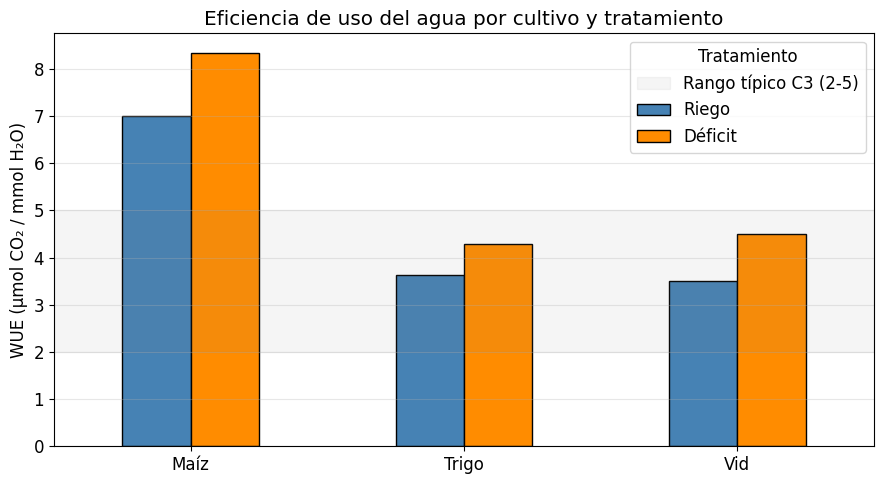

In [24]:
# SOLUCIÓN — TODO 4.3: Barras agrupadas de WUE

tabla = resumen_wue['WUE'].droplevel('Tipo').unstack('Tratamiento')[['Riego', 'Déficit']]
fig, ax = plt.subplots(figsize=(9, 5))
tabla.plot(kind='bar', ax=ax, color=['steelblue', 'darkorange'], edgecolor='black')
ax.axhspan(2, 5, color='gray', alpha=0.08, label='Rango típico C3 (2-5)')
ax.set_ylabel('WUE (μmol CO₂ / mmol H₂O)')
ax.set_xlabel('')
ax.set_title('Eficiencia de uso del agua por cultivo y tratamiento')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Tratamiento')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Pregunta de interpretación

1. ¿Qué cultivo es más eficiente en el uso del agua? ¿Se relaciona con su tipo metabólico (C3/C4)?
2. En los tres cultivos, el déficit hídrico **aumenta** la WUE. ¿Significa que conviene regar menos? ¿Qué pasa con la fotosíntesis (A)?
3. ¿Por qué la WUE intrínseca (A/gs) es útil para comparar mediciones hechas en días con distinto DPV?

### Respuesta sugerida (Parte 4)

**1.** El **maíz** (C4) tiene la mayor WUE: 7.0 con riego y 8.3 con déficit, el doble que vid (3.5 / 4.5) y trigo (3.6 / 4.3), ambos C3 y dentro del rango típico de 2-5. Las plantas C4 concentran CO₂ en las células de la vaina del haz (enzima PEP-carboxilasa), por lo que fotosintetizan mucho con estomas relativamente cerrados: su WUEi es ≈ 160-230 μmol/mol frente a 50-90 en las C3.

**2.** No necesariamente. El déficit cierra los estomas y la transpiración cae proporcionalmente más que la fotosíntesis, por eso sube la eficiencia. Pero **A baja 30-40 %** (vid 14.0 → 9.0; trigo 20.0 → 12.0; maíz 35.0 → 25.0), lo que significa menos biomasa y rendimiento. El riego deficitario conviene cuando el agua es el recurso limitante (producir más por m³) o cuando un estrés moderado mejora la calidad (vid vinífera), no para maximizar rendimiento por hectárea.

**3.** La WUE instantánea depende del DPV del momento: con aire más seco, E aumenta aunque la planta no cambie, y A/E baja. La WUEi divide por gs, que refleja la apertura estomática y no la demanda atmosférica, así que permite comparar el comportamiento fisiológico de la planta entre días, horas o sitios con distinta humedad.

---
## Parte 5: Absorción de agua por las raíces en el perfil (35 min)

En un huerto de maíz se instalaron sensores FDR a 4 profundidades (cada uno representa una capa de 25 cm). Se regó hasta capacidad de campo el día 0 y se volvió a leer θv el día 4, sin lluvia ni riego entre ambas lecturas y sin drenaje (el suelo ya estaba a CC).

Toda la disminución de θv se debe a la **extracción por raíces** (y evaporación en superficie, que aquí despreciamos):

$$\text{Extracción}_{capa} = (\theta_{v,0} - \theta_{v,4}) \times Z_{capa} \quad [\text{mm}]$$

La **regla 40-30-20-10** dice que, en un perfil dividido en cuartos de la profundidad radical, las raíces extraen ~40 %, 30 %, 20 % y 10 % del agua desde arriba hacia abajo.

In [25]:
# Lecturas de θv (cm³/cm³) por capa
perfil = pd.DataFrame({
    'Capa': ['0-25 cm', '25-50 cm', '50-75 cm', '75-100 cm'],
    'Espesor_mm': [250, 250, 250, 250],
    'Theta_dia0': [0.320, 0.300, 0.280, 0.260],
    'Theta_dia4': [0.282, 0.271, 0.261, 0.250],
    'Raices_pct': [40, 30, 20, 10]   # regla 40-30-20-10
})
dias = 4
perfil

,Capa,Espesor_mm,Theta_dia0,Theta_dia4,Raices_pct
0,0-25 cm,250,0.32,0.282,40
1,25-50 cm,250,0.30,0.271,30
2,50-75 cm,250,0.28,0.261,20
3,75-100 cm,250,0.26,0.250,10


In [26]:
# SOLUCIÓN — TODO 5.1: Extracción de agua por capa

perfil['Extraccion_mm'] = (perfil['Theta_dia0'] - perfil['Theta_dia4']) * perfil['Espesor_mm']
perfil['Extraccion_pct'] = perfil['Extraccion_mm'] / perfil['Extraccion_mm'].sum() * 100
extraccion_total = perfil['Extraccion_mm'].sum()
etc_estimada = extraccion_total / dias

display(perfil[['Capa', 'Extraccion_mm', 'Extraccion_pct', 'Raices_pct']].round(1))
print(f'Extracción total en {dias} días: {extraccion_total:.1f} mm')
print(f'ETc estimada: {etc_estimada:.1f} mm/día')

,Capa,Extraccion_mm,Extraccion_pct,Raices_pct
0,0-25 cm,9.5,39.6,40
1,25-50 cm,7.2,30.2,30
2,50-75 cm,4.8,19.8,20
3,75-100 cm,2.5,10.4,10


Extracción total en 4 días: 24.0 mm
ETc estimada: 6.0 mm/día


In [27]:
# Celda de validación
if 'Extraccion_mm' in perfil.columns and 'etc_estimada' in dir():
    ok = (np.allclose(perfil['Extraccion_mm'], [9.5, 7.25, 4.75, 2.5], atol=0.05)
          and np.isclose(etc_estimada, 6.0, atol=0.05))
    print('✓ Extracción correcta' if ok else '⚠ Revisa: extracción = Δθ × espesor (mm)')
else:
    print('⚠ Calcula Extraccion_mm y etc_estimada primero')

✓ Extracción correcta


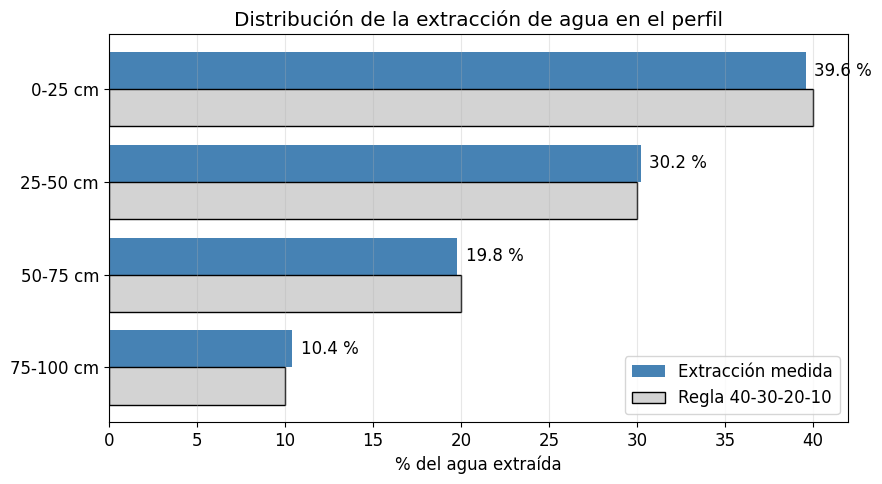

In [28]:
# SOLUCIÓN — TODO 5.2: Extracción medida vs regla 40-30-20-10

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(perfil))
ax.barh(y - 0.2, perfil['Extraccion_pct'], height=0.4, label='Extracción medida', color='steelblue')
ax.barh(y + 0.2, perfil['Raices_pct'], height=0.4, label='Regla 40-30-20-10', color='lightgray', edgecolor='black')
for yi, v in zip(y, perfil['Extraccion_pct']):
    ax.text(v + 0.5, yi - 0.2, f'{v:.1f} %', va='center')
ax.set_yticks(y)
ax.set_yticklabels(perfil['Capa'])
ax.invert_yaxis()   # superficie arriba
ax.set_xlabel('% del agua extraída')
ax.set_title('Distribución de la extracción de agua en el perfil')
ax.legend(loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Pregunta de interpretación

1. ¿La extracción medida se ajusta a la regla 40-30-20-10? ¿Qué te dice eso sobre dónde están las raíces activas del maíz?
2. Si tuvieras solo **dos** sensores para programar el riego de este huerto, ¿a qué profundidades los instalarías y por qué?
3. La primera capa pierde agua cuatro veces más rápido que la última. ¿Qué pasa si se riega con láminas pequeñas que solo mojan los primeros 25 cm? ¿Y si se aplican láminas que mojan hasta 1.5 m?

### Respuesta sugerida (Parte 5)

**1.** Sí: la extracción medida es 39.6 / 30.2 / 19.8 / 10.4 %, prácticamente igual a la regla. El 70 % del agua sale de los primeros 50 cm, donde está la mayor densidad de raíces activas (más aireación, MO y nutrientes). La tasa total de 6.0 mm/día es una estimación de la ETc del maíz en plena temporada.

**2.** Uno a **~20-30 cm** (zona de máxima densidad radical, donde el suelo se seca primero y aparece el estrés temprano) y otro a **~60-80 cm** (fondo de la zona radical: confirma que el riego llega hasta ahí sin pasarse, y detecta drenaje profundo si la humedad sube por sobre CC después de regar).

**3.** Con láminas pequeñas solo se recarga la capa superior: las capas profundas se van secando, las raíces se concentran arriba y el cultivo queda más expuesto a estrés en días de alta demanda (y se pierde más agua por evaporación directa). Con láminas que mojan hasta 1.5 m, el agua bajo 1 m queda fuera del alcance de las raíces: se pierde por **percolación profunda** y arrastra nitratos. La lámina correcta es la que repone el déficit hasta la profundidad radical efectiva (≈ AFA del perfil de 1 m, Unidad 2).

---
## Entregable del Taller 3

Al finalizar, entrega este notebook con todas las celdas completas y ejecutadas.

**Debes incluir:**
1. Ψatm calculado y tabla de ΔΨ por tramo en ambos escenarios
2. Resistencia hidráulica suelo → hoja en ambos escenarios
3. Interpretación: gradiente de potencial y efecto del suelo seco
4. DPV y transpiración horaria, con el panel de 4 gráficos del curso diario
5. Clasificación del estado hídrico por hora e interpretación de la depresión de mediodía
6. Ajuste del modelo gs–Ψhoja (gmax, k, Ψ50) con su gráfico
7. Tabla de WUE e WUEi por cultivo y tratamiento, con su gráfico
8. Interpretación: C3 vs C4 y efecto del déficit hídrico
9. Extracción de agua por capa y ETc estimada, comparada con la regla 40-30-20-10
10. Interpretación: ubicación de sensores y profundidad de riego

**Formato de entrega:** Notebook .ipynb descargado de Colab.

---
*Taller 3 (solución) — TAG2027 Relación Suelo Agua Planta | UDLA*